what is the avrage duration of matches?

step1:import libraries

In [16]:
import polars as pl
from pathlib import Path

STEP2: define project path

In [17]:
CURRENT_DIR=Path.cwd()

PROJECT_PATH=CURRENT_DIR.parent

print("project_path:",PROJECT_PATH)


project_path: /Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis


In [18]:
# List all parquet files in Data folder

data_path = PROJECT_PATH / "tennis_data" / "Data"

parquet_files=list(data_path.rglob("*.parquet"))

for file in parquet_files:
    print(file)
    
    
print("\nData_path:",data_path)

print("\nfolder exists:",data_path.exists())

/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/tournament_clean.parquet
/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/statistics_clean.parquet
/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/event.parquet
/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/season_clean.parquet
/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/tennis_power_clean.parquet
/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/votes_clean.parquet
/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/time_clean.parquet
/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/venue_clean.parquet
/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/o

In [19]:
# Search all parquet files in the whole project
all_parquet_files = list(PROJECT_PATH.rglob("*.parquet"))

# Show all found parquet files
all_parquet_files

[PosixPath('/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/tournament_clean.parquet'),
 PosixPath('/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/statistics_clean.parquet'),
 PosixPath('/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/event.parquet'),
 PosixPath('/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/season_clean.parquet'),
 PosixPath('/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/tennis_power_clean.parquet'),
 PosixPath('/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/votes_clean.parquet'),
 PosixPath('/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/time_clean.parquet'),
 PosixPath('/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/D

step3:load time dataset

In [20]:

time=pl.read_parquet(
    data_path/"time_clean.parquet"
)


In [21]:
time_unique=time.unique(
    ["match_id"]
)


In [22]:
time_unique = time_unique.with_columns(
    (
        pl.col("period_1").fill_null(0)
        +
        pl.col("period_2").fill_null(0)
        +
        pl.col("period_3").fill_null(0)
        +
        pl.col("period_4").fill_null(0)
        +
        pl.col("period_5").fill_null(0)
    ).alias("duration_seconds")
)

In [23]:
time_unique = time_unique.with_columns(
    (
        pl.col("duration_seconds") / 60
    ).alias("match_duration_minutes")
)

In [24]:
duration_clean = time_unique.filter(
    (pl.col("match_duration_minutes") > 0) &
    (pl.col("match_duration_minutes") <= 300)
)

In [38]:
duration_clean.head()

match_id,period_1,period_2,period_3,period_4,period_5,current_period_start_timestamp,snapshot_date,duration_seconds,match_duration_minutes
i64,i64,i64,i64,i64,i64,i64,date,i64,f64
12048611,2234,3549,null,null,null,1707303848,2024-02-06,5783,96.383333
12199628,1541,201,null,null,null,1711624657,2024-03-27,1742,29.033333
12059228,3260,4258,null,null,null,1707649243,2024-02-10,7518,125.3
12129382,3522,2010,5030,null,null,1709726148,2024-03-05,10562,176.033333
12024367,2758,3547,2056,null,null,1706987650,2024-02-03,8361,139.35


In [36]:
duration_clean.select(
    "match_duration_minutes"
).describe()

statistic,match_duration_minutes
str,f64
"""count""",10225.0
"""null_count""",0.0
"""mean""",102.917945
"""std""",35.587261
"""min""",0.083333
"""25%""",77.0
"""50%""",96.383333
"""75%""",124.45
"""max""",297.233333


In [37]:
duration_clean.sort(
    "match_duration_minutes",
    descending=True
).head(10)

match_id,period_1,period_2,period_3,period_4,period_5,current_period_start_timestamp,snapshot_date,duration_seconds,match_duration_minutes
i64,i64,i64,i64,i64,i64,i64,date,i64,f64
12056393,5296,7198,5340,null,null,1707571561,2024-02-09,17834,297.233333
12172233,3963,10621,3133,null,null,1710911590,2024-03-19,17717,295.283333
12170628,2821,13335,1535,null,null,1710848659,2024-03-18,17691,294.85
12131381,1930,15656,null,null,null,1709864964,2024-03-07,17586,293.1
12137174,2320,1230,13849,null,null,1709901873,2024-03-07,17399,289.983333
12197940,13584,3374,null,null,null,1711568177,2024-03-27,16958,282.633333
12174579,6033,8100,2226,null,null,1710962143,2024-03-20,16359,272.65
12194086,4200,2520,9486,null,null,1711462024,2024-03-25,16206,270.1
12173290,2555,13559,null,null,null,1710904985,2024-03-19,16114,268.566667


In [35]:
average_duration = duration_clean.select(
    pl.mean("match_duration_minutes")
)

average_duration

match_duration_minutes
f64
102.917945


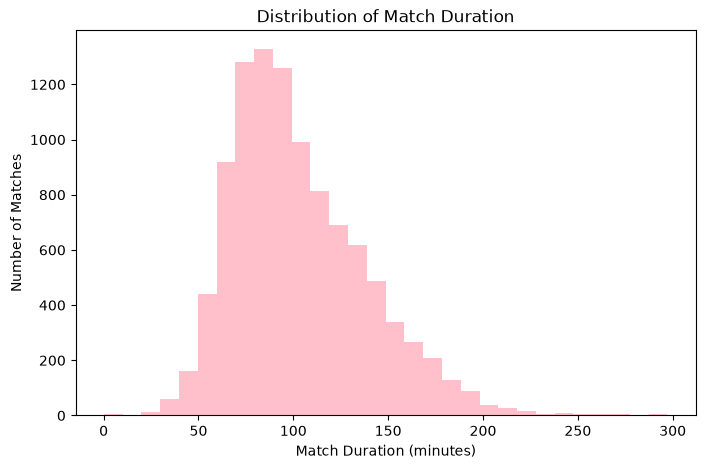

In [31]:
import matplotlib.pyplot as plt

duration_pd = duration_clean.select(
    "match_duration_minutes"
).to_pandas()

plt.figure(figsize=(8,5))

plt.hist(
    duration_pd["match_duration_minutes"],
    bins=30,
    color="pink"
)

plt.xlabel("Match Duration (minutes)")
plt.ylabel("Number of Matches")
plt.title("Distribution of Match Duration")

plt.show()

## Objective

The objective of this analysis is to calculate the average duration of tennis matches recorded in the dataset.

## Data Source

The match time information was obtained from the MatchTimeInfo table.

The following columns were used:

- period_1
- period_2
- period_3
- period_4
- period_5

These columns represent the recorded duration of different periods of each match.

Since there was no direct duration column available in the dataset, the total match duration was calculated using these period values.

## Duration Calculation Method

The total duration of each match was calculated by summing all available period durations.

Missing period values were replaced with zero because not every match contains the maximum number of periods.

The formula used was:

Duration (seconds) = period_1 + period_2 + period_3 + period_4 + period_5

The calculated duration was then converted from seconds to minutes:

Duration (minutes) = Duration (seconds) / 60

## Handling Duplicate Records

The dataset contains multiple snapshots for some matches, where the same match_id appears several times.

To avoid counting the same match multiple times, only one record per match_id was kept before calculating match durations.

## Data Cleaning and Outlier Handling

Before calculating the average duration, invalid and unrealistic values were removed.

The following conditions were applied:

- Durations greater than 0 minutes were kept to remove negative or zero values.
- Durations greater than 300 minutes were excluded as extreme outliers.

The filtering condition was:

0 < match_duration_minutes <= 300

## Reason for Removing Durations Above 300 Minutes

Some records contained extremely large duration values that were not realistic for tennis matches.

For example, without applying this condition, some matches had durations of several thousand minutes (equivalent to multiple days), which would incorrectly increase the average match duration.

These values were considered abnormal records and could distort the statistical analysis.

By removing these extreme values, the calculated average represents the typical duration of meaningful tennis matches in the dataset.

## Method

After data cleaning, the average match duration was calculated using the mean of match_duration_minutes.

## Result

The average match duration was calculated on the cleaned dataset after removing invalid and extreme duration values.

## Visualization

A histogram was created to show the distribution of match durations.

This visualization helps understand how match durations are distributed and shows the frequency of different match lengths.

## Conclusion

The average match duration was calculated using recorded period durations from the dataset.

Cleaning extreme and invalid duration values was necessary because abnormal records could significantly affect the mean and lead to misleading conclusions.